First Five Records

   SepalLength  SepalWidth  PetalLength  PetalWidth Species
0          5.1         3.5          1.4         0.2  Setosa
1          4.9         3.0          1.4         0.2  Setosa
2          4.7         3.2          1.3         0.2  Setosa
3          4.6         3.1          1.5         0.2  Setosa
4          5.0         3.6          1.4         0.2  Setosa

Selected Features

Index(['PetalLength', 'PetalWidth'], dtype='str')

Reduced Dataset Shape
(150, 2)

Explained Variance Ratio
[0.72962445 0.22850762]


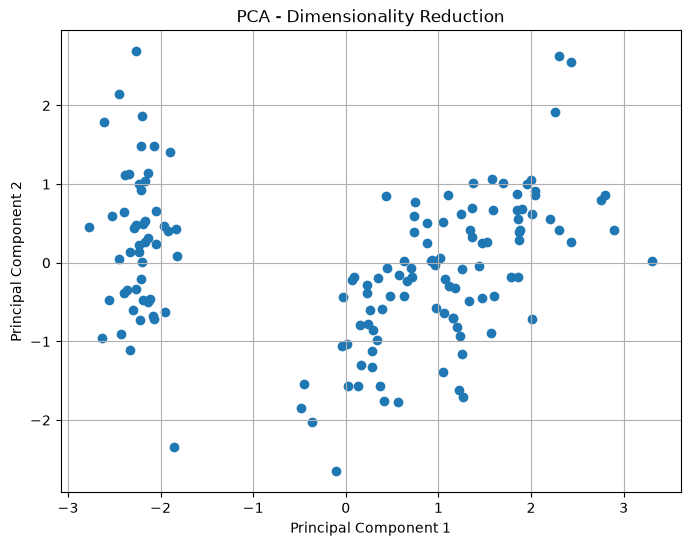

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.decomposition import PCA

# ---------------------------------------
# Step 1: Load Dataset
# ---------------------------------------

df = pd.read_csv("Iris.csv")

print("First Five Records\n")
print(df.head())

# ---------------------------------------
# Step 2: Separate Features and Target
# ---------------------------------------

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# ---------------------------------------
# Step 3: Feature Selection
# ---------------------------------------

selector = SelectKBest(score_func=f_classif, k=2)

X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]

print("\nSelected Features\n")
print(selected_columns)

# ---------------------------------------

# Step 4: Feature Scaling
# ---------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ---------------------------------------
# Step 5: Apply PCA
# ---------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nReduced Dataset Shape")

print(X_pca.shape)

print("\nExplained Variance Ratio")

print(pca.explained_variance_ratio_)

# ---------------------------------------
# Step 6: Visualize PCA
# ---------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.title("PCA - Dimensionality Reduction")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()